In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata
import scanpy

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = scanpy.read_h5ad(filename)
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


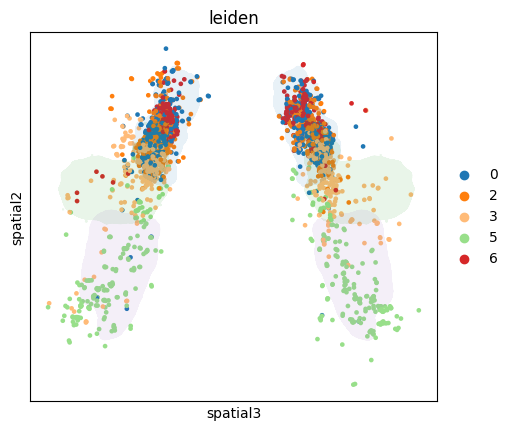

In [5]:
ax = sc.pl.embedding(adata_mer, basis = 'spatial', dimensions = (2,1), color = 'leiden', show = False)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')

In [ ]:
import scipy.spatial.distance

In [10]:
groups = adata_mer.obs.groupby('mouse_name').groups
for mouseid,cell_id in groups.items():
    adata_sub = adata_mer[cell_id]
    print(mouseid, adata_sub.shape)

MouseC (610, 315)
MouseEg (660, 315)
MouseF (509, 315)
MouseZM (872, 315)


In [86]:
adata_mer.obs.head()

,slicename,x_CCF,y_CCF,z_CCF,mouse_name,mouse_sex,_scvi_batch,_scvi_labels,leiden,sex
neuron_id,,,,,,,,,,
103685216640203968188516774531086347883,MouseC_C2,409.606844,236.687088,179.309040,MouseC,M,0,0,5,M
107556232960175669029944473037950900912,MouseC_C2,409.104832,227.210884,174.501084,MouseC,M,0,0,5,M
110143770882700220040132120043038831763,MouseC_C2,407.519014,197.276290,266.738031,MouseC,M,0,0,3,M
113385467015087615676147138608792183276,MouseC_C2,410.125922,246.485426,165.601449,MouseC,M,0,0,5,M
120882274368051877867511817169740490916,MouseC_C2,405.119627,151.984390,256.980065,MouseC,M,0,0,2,M


In [91]:
alldistlist = []
groups = adata_mer.obs.groupby('slicename').groups
for m, (mouseid, cell_id) in enumerate(groups.items()):
    adata_sub = adata_mer[cell_id]
    foo = adata_sub.obsm['spatial']
    alldist = scipy.spatial.distance.pdist(foo)
    alldistlist.append(alldist.min())
    print(mouseid, alldist.min())
#     plt.figure(figsize = (4,4));plt.hist(alldist, bins = 100);plt.title(mouseid)

MouseC_C2 0.1886053055260874
MouseC_C3 0.050543016701051574
MouseC_C4 0.16368051940992753
MouseC_C5 0.0998870096570128
MouseEg_B3 0.05917517182598183
MouseEg_Eg1 0.16808127193427175
MouseEg_Eg2 0.3856646173326174
MouseEg_Eg3 0.1296346580558195
MouseEg_Eg4 0.07128657472915921
MouseEg_Eg5 0.13194881736317285
MouseF_F1 0.1957758147193292
MouseF_F2 0.2448496345415903
MouseF_F3 0.11055602600990962
MouseF_F4 0.12245700975498068
MouseZM_ZM0 0.36252919712173914
MouseZM_ZM1 0.21882521747620784
MouseZM_ZM2 0.2625303606064892
MouseZM_ZM3 0.16415005290785623
MouseZM_ZM4 0.04342278859943449
MouseZM_ZM5p1 0.20295949047536896
MouseZM_ZM5p2 0.10947223108207564
MouseZM_ZM6p1 0.14618477188208143
MouseZM_ZM7p1 0.09758086378967314
MouseZM_ZM7p2 0.09896432621728389


Text(0, 0.5, 'minimum distance to the other cells')

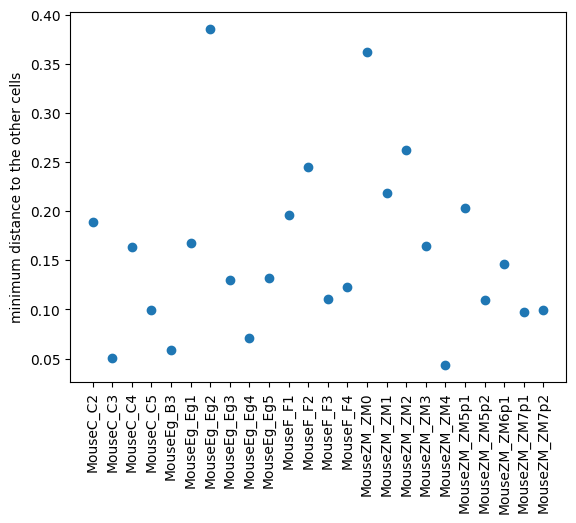

In [98]:
plt.plot(alldistlist, 'o')
plt.xticks(range(len(groups.keys())),groups.keys(), rotation = 90);
plt.ylabel('minimum distance to the other cells')

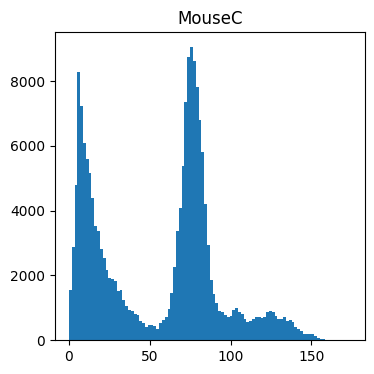

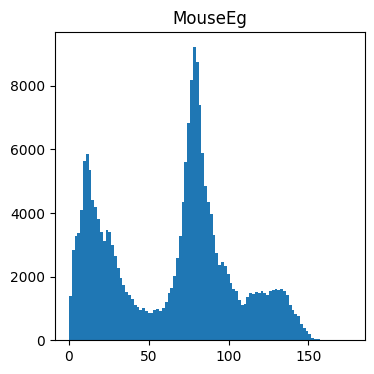

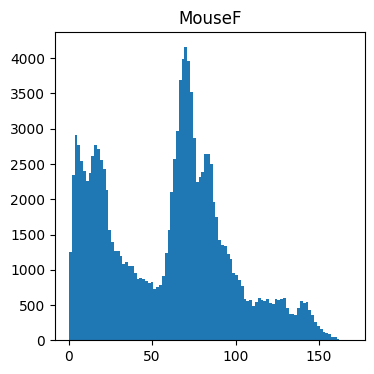

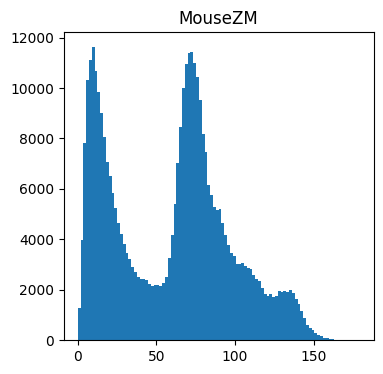

In [82]:
groups = adata_mer.obs.groupby('mouse_name').groups
for m, (mouseid, cell_id) in enumerate(groups.items()):
    adata_sub = adata_mer[cell_id]
    foo = adata_sub.obsm['spatial']
    alldist = scipy.spatial.distance.pdist(foo)
    plt.figure(figsize = (4,4));plt.hist(alldist, bins = 100);plt.title(mouseid)

In [140]:
foo = adata_mer.obsm['spatial']
tree = cKDTree(foo)
allquery = tree.query_pairs(.2, output_type='ndarray')
print(allquery.shape)

(71, 2)


In [141]:
for t in range(len(allquery)):
    i,j = allquery[t]
    if adata_mer.obs.iloc[i]['slicename'] != adata_mer.obs.iloc[j]['slicename']:
        print(adata_mer.obs.iloc[i]['slicename'], adata_mer.obs.iloc[j]['slicename'])


MouseC_C5 MouseZM_ZM7p2


In [150]:
cells_to_remove = adata_mer.obs.iloc[allquery[:,0]].index

In [152]:
adata_mer.obs.index.isin(cells_to_remove).sum()

69

In [153]:
adata_filtered = adata_mer[~adata_mer.obs.index.isin(cells_to_remove)].copy()

In [154]:
adata_filtered.shape

(2582, 315)

In [155]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_5k_filtered.h5ad'
adata_filtered.write(filename)


MouseZM_ZM6p1 MouseZM_ZM6p1
MouseC_C4 MouseC_C4
MouseC_C5 MouseC_C5
MouseF_F4 MouseF_F4
MouseZM_ZM7p1 MouseZM_ZM7p1


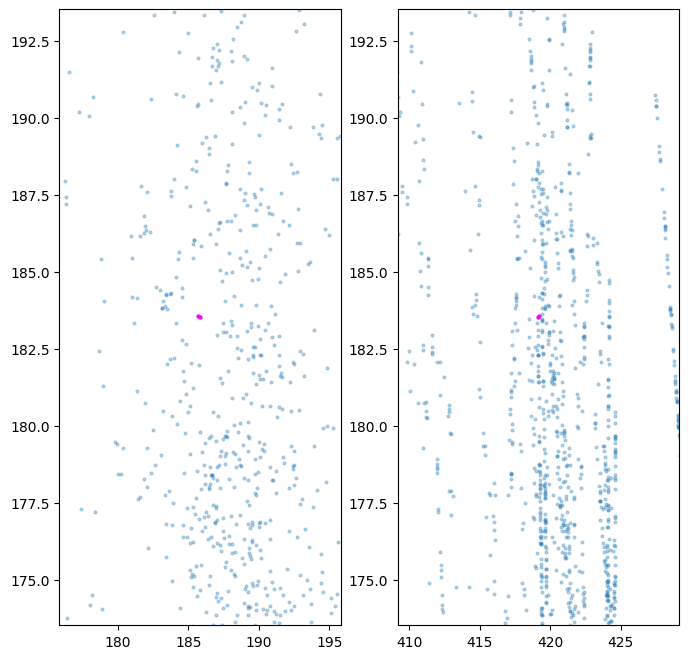

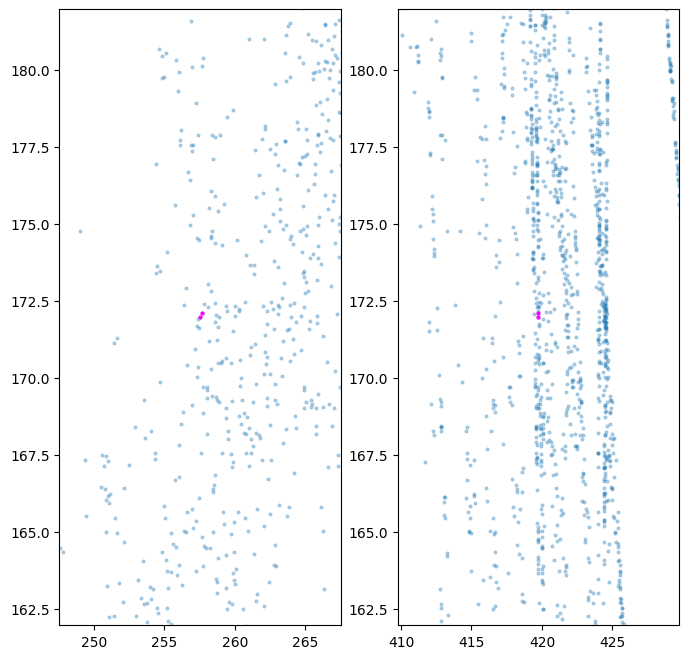

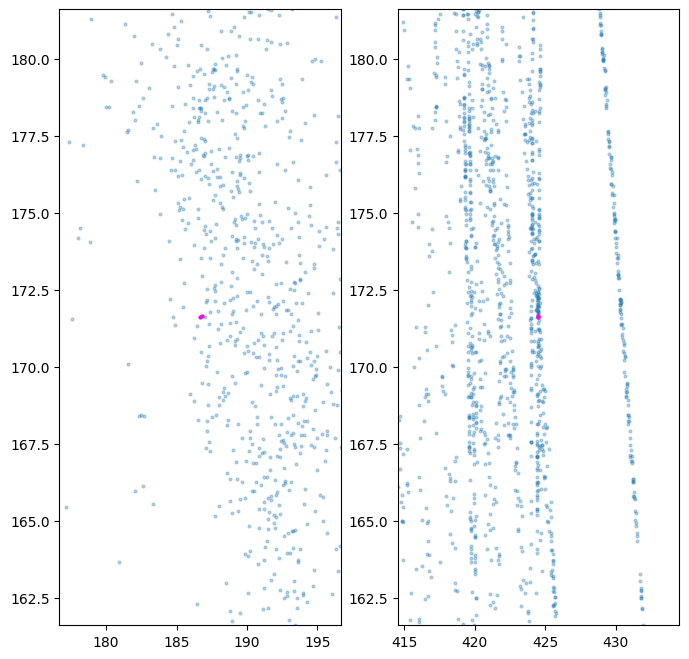

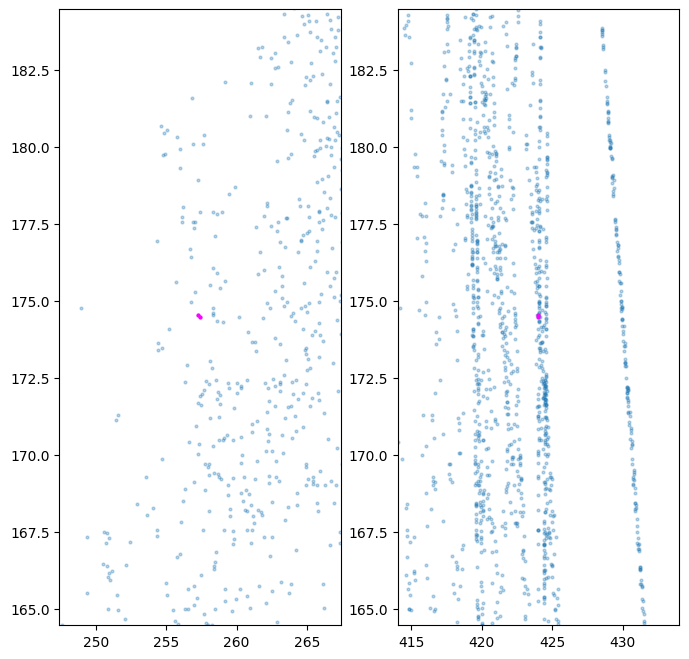

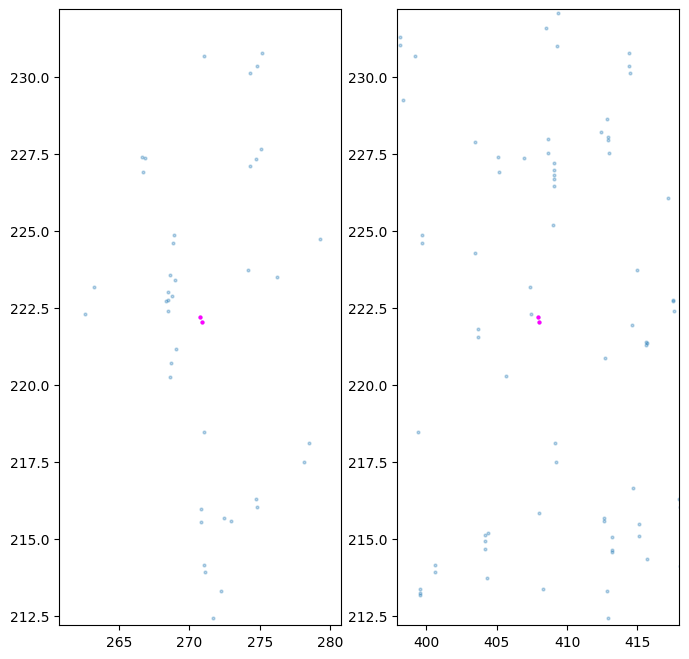

In [142]:
s = 4
r = 10
for t in np.random.choice(allquery.shape[0], size = 5):
    i,j = allquery[t]
    print(adata_mer.obs.iloc[i]['slicename'], adata_mer.obs.iloc[j]['slicename'])

    plt.figure(figsize = (8,8))
    plt.subplot(1,2,1)
    plt.scatter(foo[:,2],foo[:,1], s = s, alpha = 0.3)
    plt.scatter(foo[i,2],foo[i,1], s = s, color = 'magenta')
    plt.scatter(foo[j,2],foo[j,1], s = s,color = 'magenta')
    plt.xlim(foo[i,2]-r,foo[i,2]+r)
    plt.ylim(foo[i,1]-r,foo[i,1]+r)
    
    plt.subplot(1,2,2)
    plt.scatter(foo[:,0],foo[:,1], s = s, alpha = 0.3)
    plt.scatter(foo[i,0],foo[i,1], s = s,color = 'magenta')
    plt.scatter(foo[j,0],foo[j,1], s = s,color = 'magenta')
    plt.xlim(foo[i,0]-r,foo[i,0]+r)
    plt.ylim(foo[i,1]-r,foo[i,1]+r)

In [6]:
from scipy.spatial import distance

foo = adata_mer.obsm['spatial']
dst = distance.pdist(foo)

from scipy.spatial import cKDTree
min_dists, min_dist_idx = cKDTree(foo).query(foo, 1)
